# Regression Homework

## Data Preparation

In [354]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [355]:
df = pd.read_csv("data/car_fuel_efficiency_2026.csv", 
                 usecols=["engine_displacement",
																										"horsepower",
																										"vehicle_weight",
																										"model_year",
																										"fuel_efficiency_mpg"])

df.head()


,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


## EDA

In [356]:
df.describe()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
count,10000.000000,10000.000000,9123.000000,10000.000000,10000.000000
mean,1999.549500,2268.807000,254.446016,4286.754000,29.997700
std,14.207925,183.447355,22.844613,266.212491,2.930245
min,1975.000000,1590.000000,171.000000,3320.000000,19.800000
25%,1987.000000,2150.000000,239.000000,4110.000000,28.000000
50%,2000.000000,2270.000000,254.000000,4280.000000,30.000000
75%,2012.000000,2390.000000,270.000000,4470.000000,31.900000
max,2024.000000,3110.000000,334.000000,5460.000000,41.200000


In [357]:
for col in df.columns:
    print(col)
    print(df[col].nunique())

model_year
50
engine_displacement
127
horsepower
153
vehicle_weight
176
fuel_efficiency_mpg
188


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

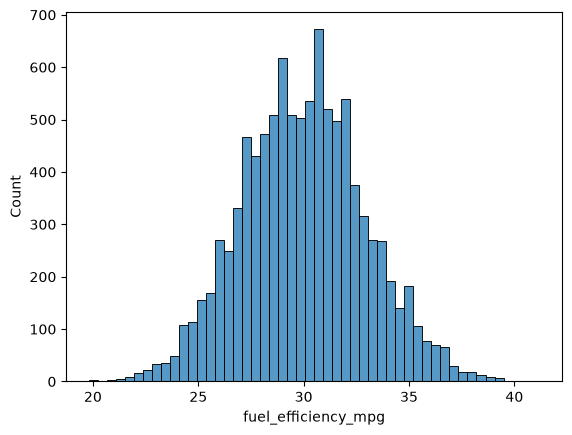

In [358]:
sns.histplot(df["fuel_efficiency_mpg"], bins=50)

- From the histogram we see that the fuel_efeciceny_mpg have a normal distribution, with most cars having an efficiency of about 31 with about 680 cars. 

##### **Q1:** Columns with Missing Values

In [359]:
df.columns[df.isna().any()]

Index(['horsepower'], dtype='str')

##### **Q2:** Horsepower 50% Percentile 

In [360]:
# percentile_50 = df["horsepower"].median()

# percentile_50 = np.percentile(df["horsepower"].dropna(), 50)

percentile_50 = np.nanpercentile(df["horsepower"], 50)

percentile_50


np.float64(254.0)

## Prepare and split the dataset

##### **Q3:**  Calculating the rmse with 0 and mean filled df

In [361]:
def shuffle_and_split(seed):
    # Number of records
				n = len(df)
				# print("Number of records: ", n)

				# Number of validation records
				n_val = int(n * 0.2)
				# print("Number of validation records: ", n_val)

				# Number of test records
				n_test= int(n * 0.2)
				# print("Number of test records: ", n_test)

				# Number of training records
				n_train = n - n_val - n_test 
				# print("Number of training records: ", n_train)

				# Shuffling the Dataframe
				# Fxing a random seed for reporducibilty
				np.random.seed(seed) 

				# Generating an array of indexes
				idx = np.arange(n)
					
				# Shuffling
				np.random.shuffle(idx)

				# Splitting the Dataframe
				df_train = df.iloc[idx[:n_train]]
				df_val = df.iloc[idx[n_train:n_train + n_val]]
				df_test = df.iloc[idx[n_train + n_val:]]

				return (df_train, df_val, df_test)

df_train, df_val, df_test = shuffle_and_split(42)
	

## Preparing y and removing fuel efficiency column

In [362]:
def get_target_y(df_train, df_val, df_test):
	y_train = df_train["fuel_efficiency_mpg"].values
	y_val = df_val["fuel_efficiency_mpg"].values
	y_test = df_test["fuel_efficiency_mpg"].values
	del df_train["fuel_efficiency_mpg"]
	del df_val["fuel_efficiency_mpg"]
	del df_test["fuel_efficiency_mpg"]

	return (y_train, y_val, y_test)

y_train, y_val, y_test = get_target_y(df_train, df_val, df_test)

## Handling Missing Values

In [363]:
def prepare_X(df, filler):
    df_num = df
    df_num = df_num.fillna(filler)
    X = df_num.values
    return X

In [364]:
X_train_0 = prepare_X(df_train, 0)
X_train_mean = prepare_X(df_train, df_train.mean())

## Training the Model

In [365]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [366]:
# Filling Missing values with 0
w0_1, w_1 = train_linear_regression(X_train_0, y_train)

In [367]:
# Filling Missing values with the Mean
w0_2,w_2 = train_linear_regression(X_train_mean, y_train)

## Predictions

In [368]:
y_val_0 = prepare_X(df_val, 0)

y_val_mean = prepare_X(df_val, df_train.mean())

In [369]:
# Predictions with 0
y_pred_1 = w0_1 + y_val_0.dot(w_1)
y_pred_1

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [370]:
# Predictions with the Mean
y_pred_2 = w0_2 + y_val_mean.dot(w_2)
y_pred_2

array([31.54288381, 29.92505122, 31.56459523, ..., 30.54408311,
       30.85701236, 31.55313717], shape=(2000,))

## Root Mean Squared Error RMSE

In [371]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [372]:
# RMSE on 0
rmse(y_val, y_pred_1)

np.float64(2.2052931947519854)

In [373]:
# RMSE on Mean
rmse(y_val, y_pred_2)

np.float64(2.201817484568829)

## Training with Regulazation

In [374]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [375]:
# Train and evluate the models

X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

rs = [0, 0.01, 0.1, 1, 5, 10, 100]
r_evaluations = {}

for r in rs:
	w0, w = train_linear_regression_reg(X_train, y_train, r)
	y_pred = w0 + X_val.dot(w)
	r_evaluations[r] = round(rmse(y_val, y_pred), 4)

r_evaluations


{0: np.float64(2.2053),
 0.01: np.float64(2.2058),
 0.1: np.float64(2.2241),
 1: np.float64(2.3492),
 5: np.float64(2.4094),
 10: np.float64(2.4195),
 100: np.float64(2.4292)}

##### **Q4:** Calculating rmse with different r and chossing the best one

- The best r is 0.

## Training with different seeds

In [376]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmses = []

for seed in seeds:
	df_train, df_val, df_test = shuffle_and_split(seed)
	y_train, y_val, y_test = get_target_y(df_train, df_val, df_test)

	X_train = prepare_X(df_train, 0)
	X_val = prepare_X(df_val, 0)  

	w0, w = train_linear_regression(X_train, y_train)
	y_pred = w0 + X_val.dot(w)

	rmses.append(rmse(y_val, y_pred))


round(np.array(rmses).std(), 3)


np.float64(0.029)

##### **Q5:** Calculating the Standard Deviation of all rmse scores for different seeds

- The Standard Deviations of all scores is 0.029

## Training and Testing

In [377]:
df_train, df_val, df_test = shuffle_and_split(9)
y_train, y_val, y_test = get_target_y(df_train, df_val, df_test)

X_train = prepare_X(pd.concat([df_train, df_val]), 0)
X_test = prepare_X(df_test, 0)  

w0, w = train_linear_regression_reg(X_train, np.concatenate([y_train, y_val]), r=0.001)
y_pred = w0 + X_test.dot(w)

round(rmse(y_test, y_pred), 3)

np.float64(2.236)

##### **Q6:** Calculating rmse with different r and chossing the best one

- The rmse is 2.236